A script to plot cross sections of the gap topography

In [1]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt

In [2]:
# Use the SE simulation data
rot = True

dycore = 'CAM-SE'
res = 'se_ne60'
test_name_start = 'cam_6_4_100'
lev_no = 'ztop20km_L57'
extra_name = 'tau_1_10'

case = f'{test_name_start}_{res}_{lev_no}'
nc_file = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name}.nc'

In [20]:
run_base = "/glade/derecho/scratch/timand/"

run_path = run_base + case + '/run/' + nc_file
nc = Dataset(run_path)
time = nc['time'][:]
lat = nc['lat'][:] 
lon = nc['lon'][:] 
lev = nc['lev'][:]

print(f'{len(lat)} latitiude points, {len(lon)} longitude points')

361 latitiude points, 720 longitude points


In [32]:
# Define crop widths in deg

lon_crop_centre = 180
lon_crop_width = 40

lat_crop_centre = 0
lat_crop_width = 40

lon_fix_ind = 360 # 0 deg for one-half degree
lat_fix_ind = 190 # 5 deg N for one-half deg

print(f'Longitude cross section is at lat = {np.round(lat[lat_fix_ind],0)} deg')

lon_crop_inds = np.where(np.abs(lon - lon_crop_centre) < lon_crop_width)
lon_crop = lon[lon_crop_inds]

lat_crop_inds = np.where(np.abs(lat - lat_crop_centre) < lat_crop_width)
lat_crop = lat[lat_crop_inds]

LONG, P_LONG = np.meshgrid(lon_crop, lev) 
LAT, P_LAT = np.meshgrid(lon_crop, lev)


Longitude cross section is at lat = 5.0 deg


In [33]:
# Extract the topography information, well the surface geopotential height
g = 9.80616
h_lon = nc['PHIS'][0,lat_fix_ind, lon_crop_inds[0]]/g
h_lat = nc['PHIS'][0,lat_crop_inds[0], lon_fix_ind]/g

saving file to figures/gap_cross_section_SE.jpg


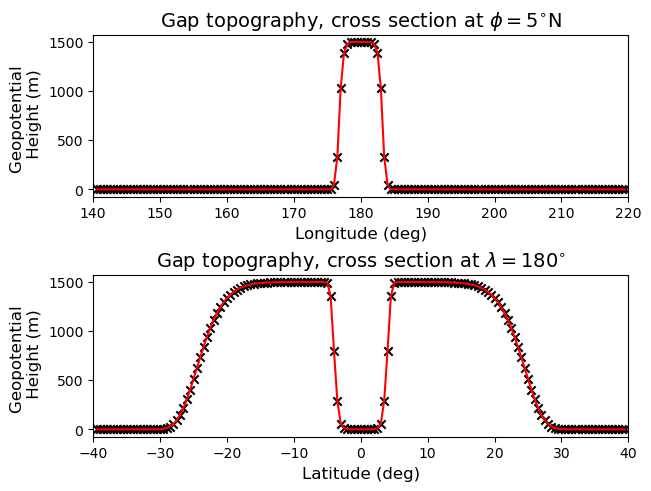

In [59]:
fig, axes = plt.subplots(2,1,constrained_layout=True)
ax1, ax2 = axes

plot1 = ax1.scatter(lon_crop, h_lon, marker='x', c='k')
plot2 = ax2.scatter(lat_crop, h_lat, marker='x', c='k')
plot1 = ax1.plot(lon_crop, h_lon, c='r')
plot2 = ax2.plot(lat_crop, h_lat, c='r')

ax1.set_ylabel('Geopotential \n Height (m)', size=12)
ax1.set_xlabel('Longitude (deg)', size=12)
ax2.set_ylabel('Geopotential \n Height (m)', size=12)
ax2.set_xlabel('Latitude (deg)', size=12)

ax1.set_xlim([140,220])
ax2.set_xlim([-40, 40])

ax1.set_title(r"Gap topography, cross section at $\phi = 5^{\circ} $N",size=14)
ax2.set_title(r"Gap topography, cross section at $\lambda = 180^{\circ} $", size=14)

#fig.suptitle(f'Mountain gap cross sections')

base_savename = f'gap_cross_section_SE.jpg'

save_name = f'figures/{base_savename}'

print(f'saving file to {save_name}')
plt.savefig(save_name)